<a href="https://colab.research.google.com/github/TeraneAgaeva/python_for_ds_tasks/blob/main/Agaeva_%22HW_2_1_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA_%D0%B4%D0%BB%D1%8F_%D0%BF%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B8_%D0%BB%D1%96%D0%BD%D1%96%D0%B8%CC%86%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [101]:
!pip install plotly matplotlib seaborn --quiet

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

In [103]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [104]:
!ls /content/drive/MyDrive/ML/ML_module_2.2

medical-charges.csv


In [105]:
medical_df = pd.read_csv('/content/drive/MyDrive/ML/ML_module_2.2/medical-charges.csv')

In [106]:
medical_df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Відповідь 1:** 1. Проаналізую перелік наявних полів в базі даних та проаналізую їх вплив на поле charges за допомогою таблиць  у python. Таким чином я визначу поля які впливають на charges, та які не впливають. Розроблю тарифну сітку опираючись на впливаючі поля (будуть критеріями тарифної сітки).  Тариф буду визначати від середнього charges по категоріям та буду застосовувати залежно від критеріїв людини яка звернулась, буду змінювати тарифи залежно від макропоказників, наприклад та націнки.
2. Проаналізую перелік наявних полів в базі даних та проаналізую їх вплив на поле charges за допомогою графіків  у python. Таким чином я визначу поля які впливають на charges, та які не впливають. Розроблю тарифну сітку опираючись на впливаючі поля (будуть критеріями тарифної сітки).  Тариф буду визначати від середнього charges по категоріям та буду застосовувати залежно від критеріїв людини яка звернулась, буду змінювати тарифи залежно від макропоказників, наприклад та націнки.
3. Якщо я аналітик то звернусь до бізнеса, щоб дізнатись їх плани на розширення продукта чи зміну продукта, у бізнеса уточню чи вірні мої аналітичні висновки. Після обговорення з бізнесом врахую в свої розрахунках п1 та п2 плани, які є у бізнеса на майбутнє

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [107]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'grey'],
                   title='Annual Medical Charges by Sex')
fig.update_layout(bargap=0.1)
fig.show()

In [108]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='region',
                   color_discrete_sequence=['red', 'grey', 'green', 'blue'],
                   title='Annual Medical Charges by Region')
fig.update_layout(bargap=0.1)
fig.show()

**Відповідь 2:** Графік 1: Аналізуючи перший графік, ми бачимо, що медичні збори для жінок є в загальній сумі меньшими та тариф для жінок нижчий. Медіана для жінок і чоловіків майже співпала. В обох категоріях є не дуже великі витрати до 15 тис та в обох категоріях є дуже великі затрати, але у чоловіків дещо більше.

Графік 2: Аналізуючи другий графік, бачимо що дані в основному зосереджені в межах 12 тис, тобто можемо сказати, що основна частина витрат до 12 тис. Але аналізуючи окремі регіони, все ж таки можемо виділити відмінності. Найширший розподіл по регіону southeast до 20 тис і є викиди більші за 60 тис. Можемо зробити висновок, що найбільші медичні збори у регіоні southeast. На другому місці northeast - основні витрати до 17 тис. А далі інші регіони

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [109]:
px.histogram(medical_df, x='smoker', color='region', title='Smoker')

In [110]:
px.histogram(medical_df, x='smoker', color='children', title='Smoker')

Відповідь 3: Аналізуючи Графік 1  бачимо, що загальна кількість курців меньша ніж тих, хто не курить (навіть якщо не всі зізнаються).  У регіоні  southeast курців найбільше, хоча в цьому ж регіоні і некурців більше. Розподіл по курцям між регіонами суттєво не відрізняється.
Графік 2 демонструє наявність дітей у курців та тих, хто не курить. Враховуючи, що некурців більше то і відповідно їх більша кількість з дітьми. Але візуально у некурців відсотків 40% тих, хто не має дітей, як і серед курців. Багатодітні від 5 дітей - тільки не курці.

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [111]:
fig = px.violin(medical_df,
                x='children',
                y='charges',
                box=True,         # Добавляет box plot (ящик с усами) внутрь каждой скрипки
                points="all",     # Отображает все точки данных поверх скрипки
                color='children',
                title='Annual Medical Charges Distribution by Number of Children',
                labels={'children': 'Number of Children', 'charges': 'Annual Medical Charges'},
               width=1000,  # Ширина в пикселях
                height=600   # Высота в пикселях
               )

fig.update_layout(xaxis_title='Number of children',
                  yaxis_title='Annual Medical Charges')

fig.show()

**Відповідь 4:** Більшість людей мають витрати від 0 до 15 тис не залежно від кількості дітей. Проте людей з 4-5 дітьми дуже мало тому у них витрат найменьше.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [112]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [113]:
def estimate_charges(age, w, b):
    return w * age + b

In [114]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

In [115]:
est_char1 = estimate_charges(30, 100, 200)
print(est_char1)

3200


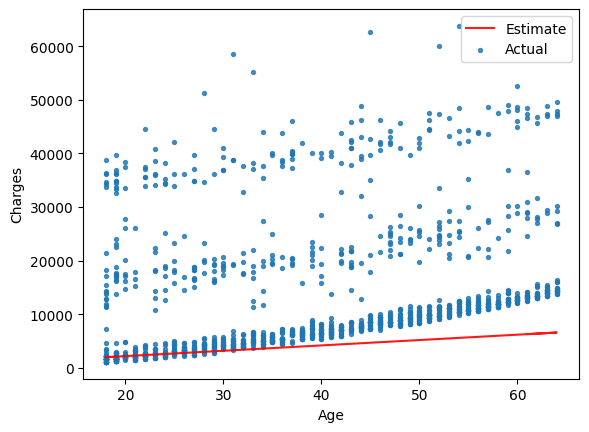

In [116]:
try_parameters(medical_df, 100, 200)

In [133]:
est_char2 = estimate_charges(30, 210, 0)
print(est_char2)

6300


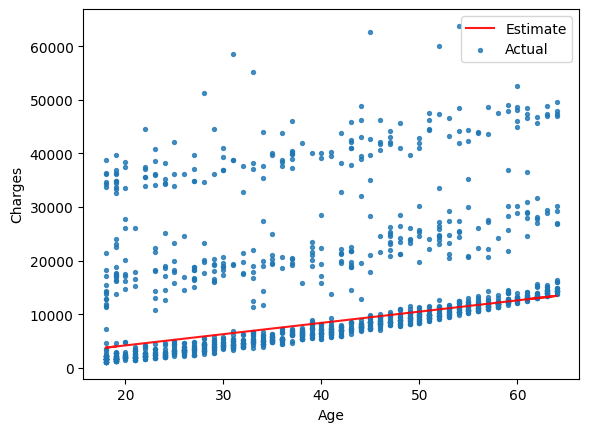

In [118]:
try_parameters(medical_df, 210, 0)

In [132]:
est_char3 = estimate_charges(30, 200, 0)
print(est_char2)

6000


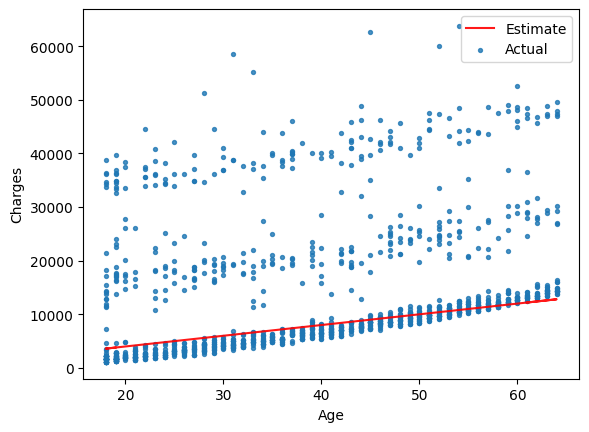

In [120]:
try_parameters(medical_df, 200, 0)

**Відповідь 5:** Експерементуючи, бачу w - впливає на кут лінії, а b - впливає на те де буде початок лінії

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [121]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [128]:
rmse1 = rmse(non_smoker_df.charges, est_char1)
print(rmse1)

7955.452257232566


In [135]:
rmse2 = rmse(non_smoker_df.charges, est_char2)
print(rmse2)

6359.77650317983


In [134]:
rmse3 = rmse(non_smoker_df.charges, est_char3)
print(rmse3)

6466.631128270114


In [136]:
min(rmse1, rmse2, rmse3)

np.float64(6359.77650317983)

In [137]:
rmse_values = [
    ("rmse1", rmse1),
    ("rmse2", rmse2),
    ("rmse3", rmse3)
]

In [138]:
# Используем функцию min() с аргументом key для поиска по второму элементу кортежа (значению RMSE)
best_rmse_info = min(rmse_values, key=lambda item: item[1])


In [139]:
print(f"Найменьший RMSE - це {best_rmse_info[0]} зі значенням {best_rmse_info[1]:.2f}.")

Найменьший RMSE - це rmse2 зі значенням 6359.78.


**Відповідь 6:** можемо зробити висновок, що чим меньше коренева середньоквадратична помилка (RMSE) тим краще підібрані параметри. Якщо rmse2 є найменьшим значенням, то набір параметрів est_char2 був підібраний більш влучно.